In [1]:
#Description: Plot depth for a given event
import os
import sys
os.environ['MPLCONFIGDIR'] = os.getcwd() + "/configs/"
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pygmt

try:
    MLDir = os.getenv('MLDir')
    SimDir = os.getenv('SimDir')
    reg = 'CT'
    mode = 'compare'
    train_size = '1658'
    mask_size = '892'
except:
    raise Exception("*** Must first set environment variable")

#set seed
np.random.seed(0)


#dimensions and gauge numbers
if reg == 'SR':
    GaugeNo = list(range(53,58)) #rough pick for Siracusa
    columnname = str(54)
    x_dim = 1300  #lon
    y_dim = 948 #lat
    ts_dim = len(GaugeNo) #gauges time series
    pts_dim = 480 #time steps
    list_size = ['961','1773','3669','6941']
    control_points = [[37.01,15.29],
        [37.06757,15.28709],
        [37.05266,15.26536],
        [37.03211,15.28632]]   
    
elif reg == 'CT':
    GaugeNo = list(range(35,44)) #for Catania
    columnname = str(38)
    x_dim = 912
    y_dim = 2224
    ts_dim = len(GaugeNo)
    pts_dim = 480
    list_size = ['892','1658','3454','7071'] 
    control_points =  [[37.5022,15.0960],
        [37.48876,15.08936],
        [37.47193,15.07816],
        [37.46273,15.08527],
        [37.46252,15.08587],
        [37.45312,15.07874],
        [37.42821,15.08506],
        [37.40958,15.08075],
        [37.38595,15.08539],
        [37.35084,15.08575],
        [37.33049,15.07029],
        [37.40675,15.05037]]


    #predictions and post processed predictions 
    eve_id = np.loadtxt('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/events/sample_events53550.txt',dtype='str')   
    #inundation attributes
    flood_mask = ~np.load(f'{MLDir}/data/processed/zero_mask_{reg}_{mask_size}.npy')
    nflood_grids = np.count_nonzero(flood_mask)
    zero_mask = np.load(f'{MLDir}/data/processed/zero_mask_{reg}_{mask_size}.npy')
    index_map = pd.read_csv(f'{MLDir}/data/processed/lat_lon_idx_{reg}_{mask_size}.txt',sep=',',header=None)
    index_map.columns = ['m','n','lat','lon'] #add column names



In [2]:
#plotting the below events
ids = [
    # 'BS_manning003/E01267N3753E01646N3535-BS-M809_E01502N3737_D010_S112D70R270_A006995_S075',
    'BS_manning003/E01267N3753E01646N3535-BS-M809_E01502N3737_D144_S022D70R270_A006995_S075',
    # 'PS_manning003/E02020N3739E02658N3366-PS-Str_PYes_Var-M902_E02417N3454_S001',
    # 'BS_manning003/E01267N3753E01646N3535-BS-M809_E01547N3670_D010_S337D70R270_A006995_S075',
    # 'BS_manning003/E01267N3753E01646N3535-BS-M809_E01495N3692_D010_S022D50R270_A006995_S075',
    # 'BS_4-8_manning003/E01267N3753E01646N3535-BS-M809_E01502N3737_D010_S067D90R090_A006995_S075',
    # 'BS_manning003/E01267N3753E01646N3535-BS-M809_E01523N3692_D010_S292D50R270_A006995_S075',
    # 'PS_manning003/E02020N3739E02658N3366-PS-Str_PYes_Var-M895_E02351N3465_S003',
    # 'BS_4-8_manning003/E01267N3753E01646N3535-BS-M809_E01551N3692_D010_S112D90R090_A006995_S075',
    ]

for id in ids:
    eve = np.where(eve_id==id)[0][0]
    print(id,'\n',eve)

    
    #additional region specific parameters for plotting
    if reg == 'CT':
        pos = "TL"
        cbar_ht = 0.02
        # Load the elevation from netcdf grid
        grid = xr.open_dataset(f'{MLDir}/data/processed/CT_defbathy.nc',engine='netcdf4')

    elif reg == 'SR':
        pos = "BL"
        cbar_ht = 0.04
        # Load the elevation from netcdf grid
        grid = xr.open_dataset(f'{MLDir}/data/processed/SR_defbathy.nc',engine='netcdf4')
    
    #get lat long limits from the grid
    ymin = grid['y'].min().values
    ymax = grid['y'].max().values
    xmin = grid['x'].min().values
    xmax = grid['x'].max().values

    #color maps
    cptfile_bathy = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/bathy_error.cpt'   

    true_depths = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/direct/PTHA/true_d_53550.npy')
    true=true_depths[eve]/100
 


BS_manning003/E01267N3753E01646N3535-BS-M809_E01502N3737_D144_S022D70R270_A006995_S075 
 29746


xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values


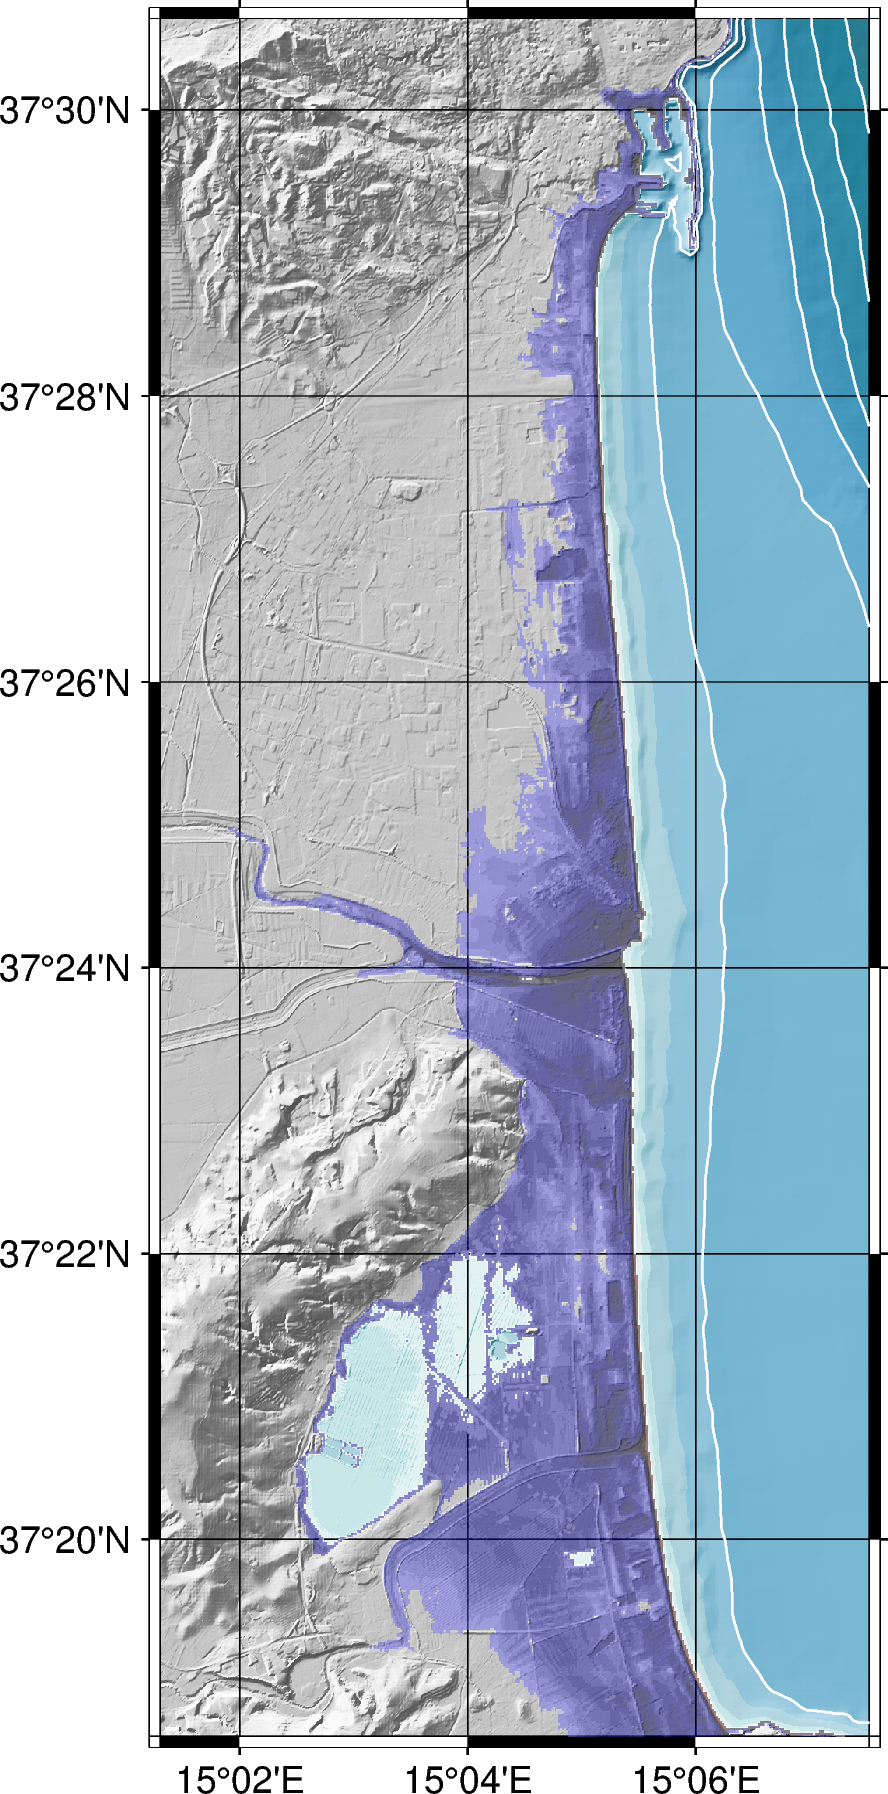

In [3]:
fig = pygmt.Figure()
cmap = pygmt.makecpt(cmap=cptfile_bathy,continuous=False)
fig.grdimage(grid['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame=["ag", "x+lLongitude", "y+lLatitude"])
fig.grdcontour(grid['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')


pygmt.makecpt(cmap="split", series=[0.1,10,0.5],transparency=10,reverse = False)     
filter = np.isfinite(true) & (true > 0.1)         
grid_depth = pygmt.xyz2grd(x=index_map['lon'][filter], y=index_map['lat'][filter], z=true[filter], spacing='1s', region=[xmin,xmax,ymin,ymax])
fig.grdimage(grid_depth, cmap=True, projection='M6c', nan_transparent=True, transparency=50)  # 20% transparent
# fig.colorbar(cmap=cmap, frame=["a10f1", "x+lDepth (m)"], position=f"j{pos}/w6c/0.5c+h+o0.2c/0.2c")
fig.show()

In [10]:
# a small function to help with depth limits
import math
def truncate_down(n):
    return(math.floor(n/100)*100)

def truncate_up(n):
    return(math.ceil(n/100)*100)

# create a custom colormap for some maps
def create_custom_cpt(min_depth,max_depth):

    # set limits for depth
    min_d = truncate_down(min_depth)
    max_d = truncate_down(max_depth)

    # create the colormap
    bathy_cpt = pygmt.makecpt(cmap='abyss',output='bathy.cpt',series=f'{min_d}/0/50',continuous=True)
    topo_cpt = pygmt.makecpt(cmap='gray',output='topo.cpt',series=f'0/{max_d}/50')

    with open('bathy.cpt') as f:
        contents_bathy = f.readlines()
    with open('topo.cpt') as f:
        contents_topo = f.readlines()

    # merge colormap
    with open('combo.cpt', 'w') as f:
        f.writelines(contents_bathy[0:-3])
        f.writelines(contents_topo)

    f.close()
    return

In [11]:
bound = [xmin,xmax,ymin,ymax]

topobathy = pygmt.grdcut(grid=grid['z'],region=bound,verbose='q')

# Note the max and min elevation in the grid region

min_ele = topobathy.min().values
max_ele = topobathy.max().values

min_ele = truncate_down(min_ele)
max_ele = truncate_up(max_ele)

print(f'IBCSO-Deception area has a minimum depth of {min_ele:.1f}'
      f' and maximum of {max_ele:.1f} meters relative to sea level.')

# create a custom colormap for these min max depths
create_custom_cpt(min_ele,max_ele)

IBCSO-Deception area has a minimum depth of -100.0 and maximum of 300.0 meters relative to sea level.


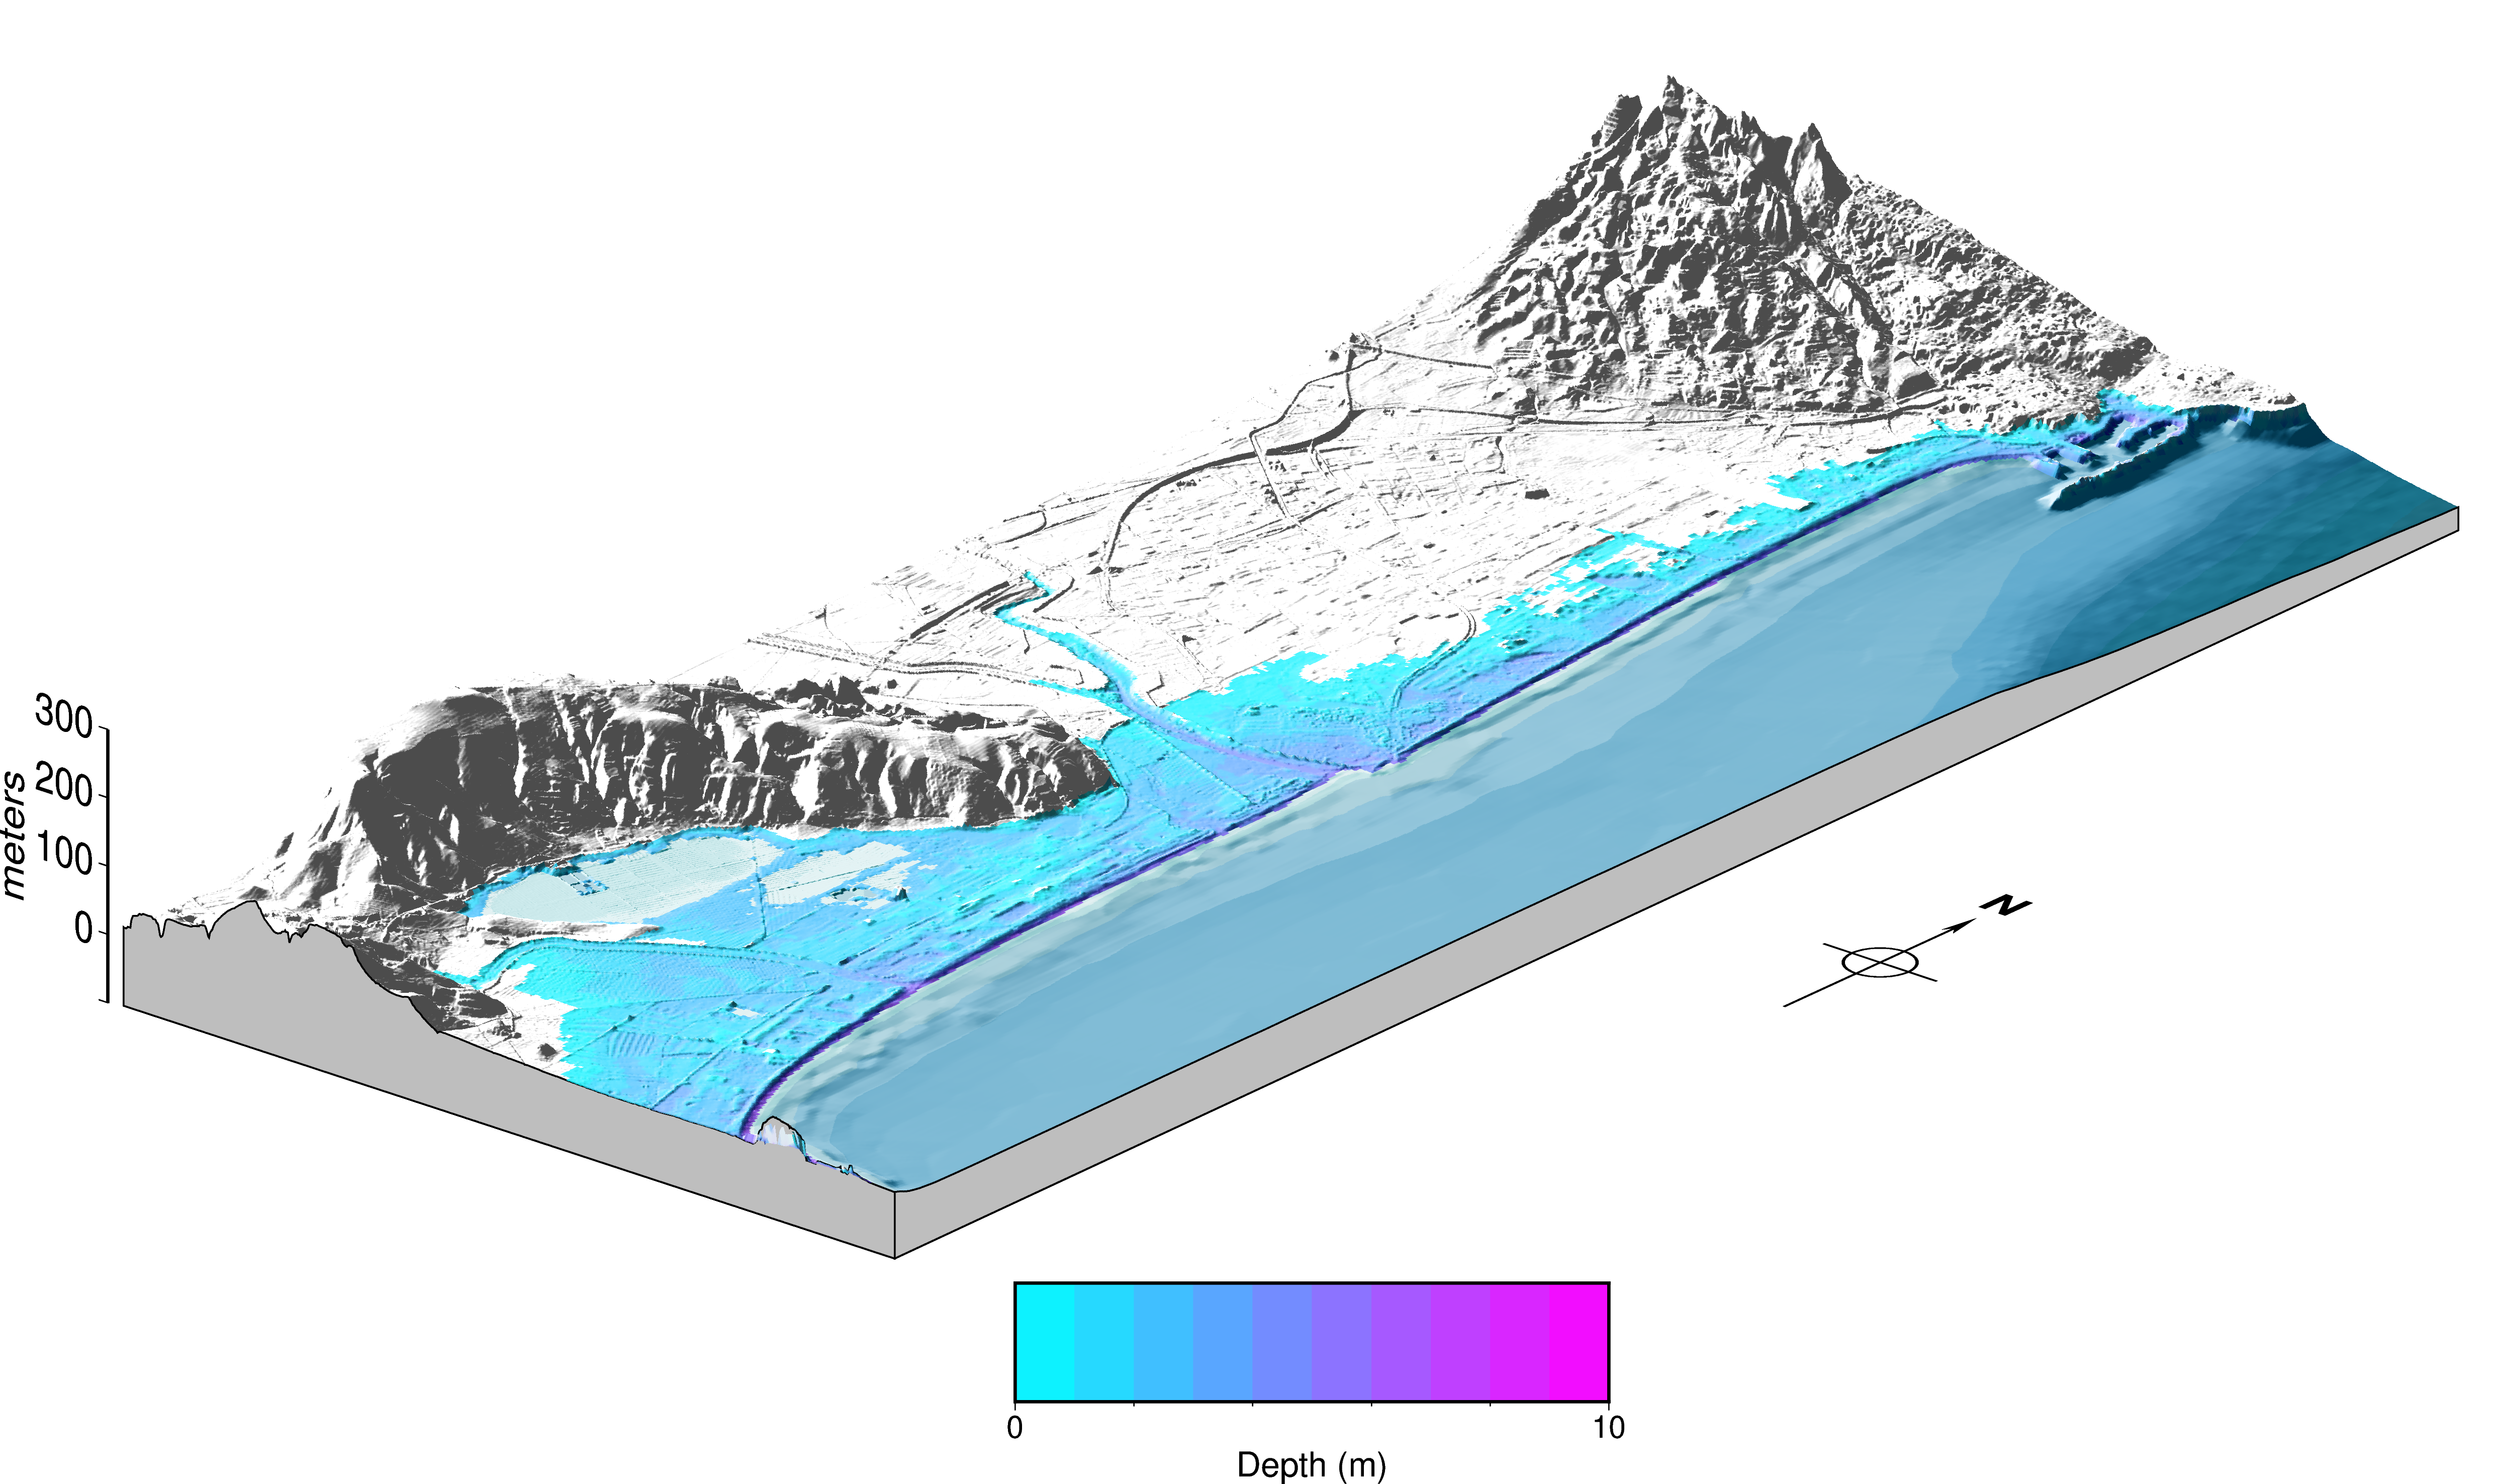

In [ ]:
fig = pygmt.Figure()

with pygmt.config(FORMAT_GEO_MAP="ddd.xxF", MAP_FRAME_TYPE="fancy",FONT='22p'):
    #color maps
    cptfile_bathy = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/bathy_error.cpt'    
    cmap = pygmt.makecpt(cmap=cptfile_bathy,continuous=False,overrule_bg=True)
    fig.grdview(grid=topobathy,
                region=bound+[min_ele,max_ele],
                frame=["z100+lmeters","wSEnZ"],
                perspective=[140,23], # set the perspective here
                projection='M18c', # projection use is Mercartor
                zsize='5c',
                surftype='c',
                cmap=True, # use the custom colormap created above
                plane=f"{min_ele}+ggrey",
                shading='+a270+nt2')
    
    pygmt.makecpt(cmap="cool", series=[0, 10,1],continuous = False,overrule_bg=True)

    fig.grdview(grid=topobathy,
                drapegrid=grid_depth,  # Drap image grid on top
                region=bound+[min_ele,max_ele],
                frame=["z100+lmeters","wSEnZ"],
                perspective=[140,23], # set the perspective here
                projection='M18c', # projection use is Mercartor
                zsize='5c',
                surftype='c',
                cmap=True, # use the custom colormap created above
                shading='+a270+nt1.5',
                transparency=20, # make the drape grid semi-transparent
                )

    fig.basemap(
        perspective=True,
        rose="JCR+w5c+l+o2.5c/0c" # map directional rose at the center (MAP) right with a little shift
    )

with pygmt.config(FONT='16p', FONT_ANNOT='18p', FONT_LABEL='20p'):
    fig.colorbar(
        cmap=cmap,
        frame=["a10f2", "x+lDepth (m)"],
        position="JBC+w10c/2c+h+o0.2c/0.2c",
    )

fig.show()

Inundation with time history

In [ ]:
#ncfile read
grid_ts = xr.open_dataset(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/BS_4-8_manning003_extreme_ts/E00979N4372E01586N3827-BS-M809_E01517N3827_D010_S157D70R090_A006995_S075/grid0_ts.nc',engine='netcdf4')
grid_ts

In [ ]:
fig = pygmt.Figure()
fig.basemap(region=bound, projection="M6i", frame=True)
fig.coast(shorelines=True, water="skyblue", land="gray", resolution="i")
h =grid_ts.deformed_bathy.values,
eta=grid_ts.eta[0].values,
d= eta-h
fig.plot(
    x=grid_ts.longitude.values,
    y=grid_ts.latitude.values,
    fill = d,
    style="s0.5c",
    cmap='cool'
)
fig.show()

In [ ]:
for t in range(2):

    fig = pygmt.Figure()

    with pygmt.config(FORMAT_GEO_MAP="ddd.xxF", MAP_FRAME_TYPE="fancy",FONT='22p'):
        #color maps
        cptfile_bathy = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/bathy_error.cpt'    
        cmap = pygmt.makecpt(cmap=cptfile_bathy,continuous=False,overrule_bg=True)
        fig.grdview(grid=topobathy,
                    region=bound+[min_ele,max_ele],
                    frame=["z100+lmeters","wSEnZ"],
                    perspective=[140,23], # set the perspective here
                    projection='M18c', # projection use is Mercartor
                    zsize='5c',
                    surftype='c',
                    cmap=True, # use the custom colormap created above
                    plane=f"{min_ele}+ggrey",
                    shading='+a270+nt2')
        
        pygmt.makecpt(cmap="cool", series=[0, 10,1],continuous = False,overrule_bg=True)
        x = grid_ts.longitude.values
        y = grid_ts.latitude.values
        z = grid_ts.eta[t].values  # eta at timestep 0
        bathy = grid_ts.deformed_bathy.values  # bathymetry values
        d = z + bathy  # difference between eta and bathymetry
        # 2. Convert to grid
        grid_dep_ts = pygmt.xyz2grd(x=x, y=y, z=d, spacing='5s', region=[xmin,xmax,ymin,ymax])


        fig.grdview(grid=topobathy,
                    drapegrid=grid_dep_ts,  # Drap image grid on top
                    region=bound+[min_ele,max_ele],
                    frame=["z100+lmeters","wSEnZ"],
                    perspective=[140,23], # set the perspective here
                    projection='M18c', # projection use is Mercartor
                    zsize='5c',
                    surftype='c',
                    cmap=True, # use the custom colormap created above
                    shading='+a270+nt1.5',
                    transparency=20, # make the drape grid semi-transparent
                    )

        fig.basemap(
            perspective=True,
            rose="JCR+w5c+l+o2.5c/0c" # map directional rose at the center (MAP) right with a little shift
        )

    with pygmt.config(FONT='16p', FONT_ANNOT='18p', FONT_LABEL='20p'):
        fig.colorbar(
            cmap=cmap,
            frame=["a10f2", "x+lDepth (m)"],
            position="JBC+w10c/2c+h+o0.2c/0.2c",
        )

    fig.show()
